In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("D:\\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [4]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [5]:
#Data Inspection
def data_audit(df):

    audit = pd.DataFrame({
        "Column": df.columns,
        "Datatype": df.dtypes,
        "Missing Values": df.isna().sum(),
        "Unique Values": df.nunique()
    })

    return audit

data_audit(df)

,Column,Datatype,Missing Values,Unique Values
transaction_id,transaction_id,object,0,7500
user_id,user_id,object,0,7500
age,age,int64,0,18
gender,gender,object,0,3
daily_screen_time_hours,daily_screen_time_hours,float64,0,900
social_media_hours,social_media_hours,float64,0,551
gaming_hours,gaming_hours,float64,0,401
work_study_hours,work_study_hours,float64,0,551
sleep_hours,sleep_hours,float64,0,451
notifications_per_day,notifications_per_day,int64,0,231


In [6]:
df = df.drop_duplicates() #Removing duplicates

In [7]:
df = df.fillna(df.median(numeric_only=True)) # filling missing values

In [8]:
#Outlier Inspection
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} → {len(outliers)} outliers")

age → 0 outliers
daily_screen_time_hours → 0 outliers
social_media_hours → 0 outliers
gaming_hours → 0 outliers
work_study_hours → 0 outliers
sleep_hours → 0 outliers
notifications_per_day → 0 outliers
app_opens_per_day → 0 outliers
weekend_screen_time → 0 outliers
addicted_label → 0 outliers


In [9]:
# creating total entertainment hours to track all mobile hours
df["total_entertainment_hours"] = (df["social_media_hours"] +df["gaming_hours"])
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0,2.90
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0,6.05
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,5.19
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,7.36
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,9.34


In [10]:
#Creating Productivity Ratio
df["productivity_ratio"] = (df["work_study_hours"] /df["daily_screen_time_hours"])
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours,productivity_ratio
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0,2.90,1.408669
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0,6.05,0.872299
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,5.19,0.387789
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,7.36,0.452107
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,9.34,0.529116


In [11]:
# Creating column counting sleep deficit
df["sleep_deficit"] = 8 - df["sleep_hours"]
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours,productivity_ratio,sleep_deficit
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0,2.90,1.408669,0.45
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0,6.05,0.872299,0.34
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,5.19,0.387789,3.08
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,7.36,0.452107,-0.23
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,9.34,0.529116,1.79


In [12]:
# Creating a column of notification intensity
df["notification_intensity"] = (df["notifications_per_day"]/df["app_opens_per_day"])
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours,productivity_ratio,sleep_deficit,notification_intensity
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0,2.90,1.408669,0.45,1.610390
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0,6.05,0.872299,0.34,1.788732
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,5.19,0.387789,3.08,0.415094
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,7.36,0.452107,-0.23,1.663551
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,9.34,0.529116,1.79,0.768362


In [13]:
# Creating a column to track online time in the weekends
df["weekend_usage_spike"] = (df["weekend_screen_time"]-df["daily_screen_time_hours"])
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours,productivity_ratio,sleep_deficit,notification_intensity,weekend_usage_spike
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,...,3.95,Medium,Yes,NaN,0,2.90,1.408669,0.45,1.610390,0.72
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,...,6.71,Medium,Yes,NaN,0,6.05,0.872299,0.34,1.788732,1.62
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,...,8.68,High,No,Mild,0,5.19,0.387789,3.08,0.415094,2.62
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,...,9.77,High,Yes,Moderate,1,7.36,0.452107,-0.23,1.663551,1.94
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,...,12.55,Low,No,Severe,1,9.34,0.529116,1.79,0.768362,2.59


In [14]:
#Creating age group bins
df["age_group"] = pd.cut(
    df["age"],
    bins=[15,20,25,30,35,40],
    labels=[
        "15-20",
        "21-25",
        "26-30",
        "31-35",
        "36-40"
    ]
)
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,stress_level,academic_work_impact,addiction_level,addicted_label,total_entertainment_hours,productivity_ratio,sleep_deficit,notification_intensity,weekend_usage_spike,age_group
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,...,Medium,Yes,NaN,0,2.90,1.408669,0.45,1.610390,0.72,21-25
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,...,Medium,Yes,NaN,0,6.05,0.872299,0.34,1.788732,1.62,21-25
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,...,High,No,Mild,0,5.19,0.387789,3.08,0.415094,2.62,31-35
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,...,High,Yes,Moderate,1,7.36,0.452107,-0.23,1.663551,1.94,31-35
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,...,Low,No,Severe,1,9.34,0.529116,1.79,0.768362,2.59,21-25


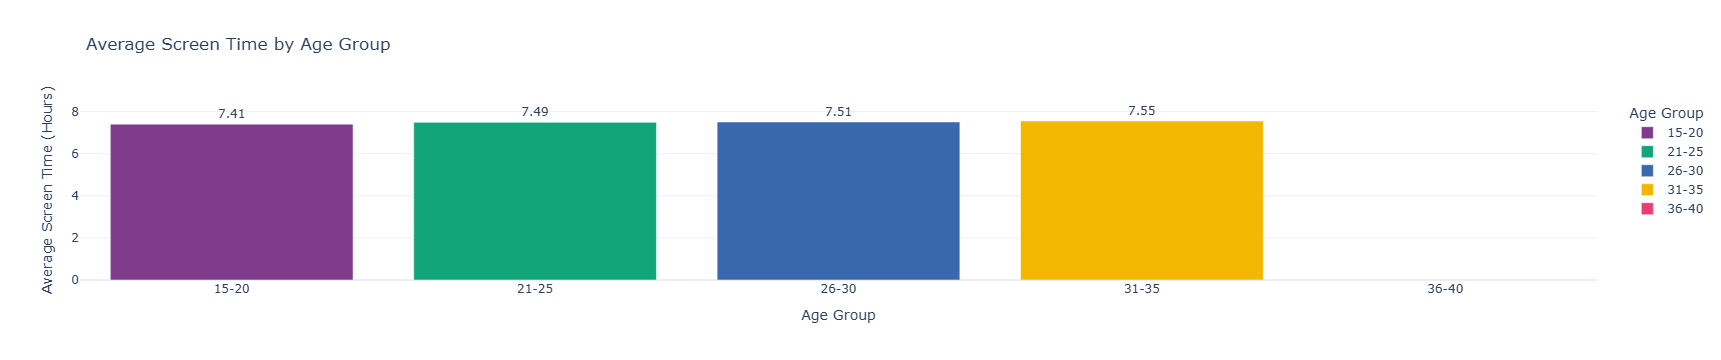

In [15]:
# calculation and visualisation of average screen time by age groups 
age_screen = (
    df.groupby("age_group")["daily_screen_time_hours"]
    .mean()
    .reset_index()
)

fig = px.bar(
    age_screen,
    x="age_group",
    y="daily_screen_time_hours",
    color="age_group",
    title="Average Screen Time by Age Group",
    labels={
        "age_group": "Age Group",
        "daily_screen_time_hours": "Average Screen Time (Hours)"
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    text="daily_screen_time_hours"
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Age Group",
    yaxis_title="Average Screen Time (Hours)",
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)
fig.update_layout(yaxis_range=[0, age_screen["daily_screen_time_hours"].max()+1])
fig.show()

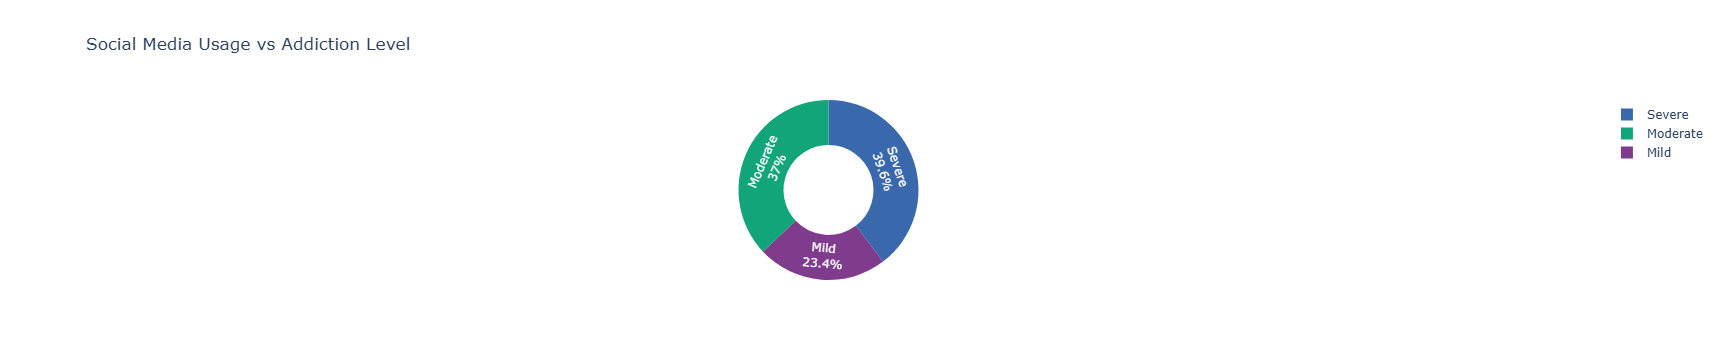

In [16]:
#calcualtion and visuaisation of social media usage vs addiction level
social_media_analysis = (
    df.groupby("addiction_level")["social_media_hours"]
    .mean()
    .reset_index()
)
fig = px.pie(
    social_media_analysis,
    names="addiction_level",
    values="social_media_hours",
    title="Social Media Usage vs Addiction Level",
    hole=0.5,
    color="addiction_level",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Average Social Media Hours: %{value:.2f}<br>Percentage: %{percent}"
)

fig.show()

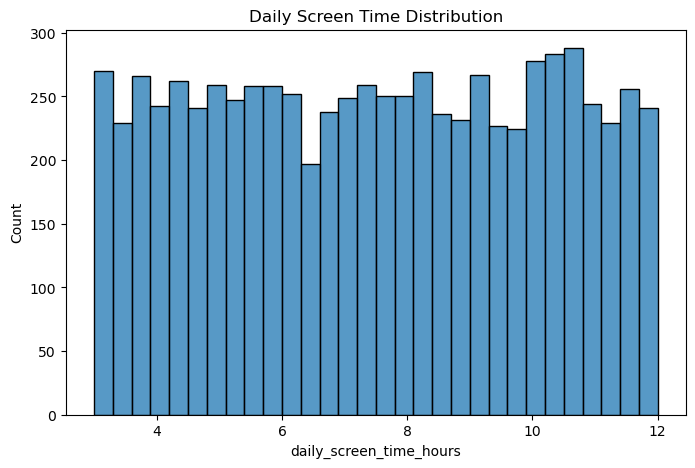

In [17]:
#Daily screen time distrubution
plt.figure(figsize=(8,5))

sns.histplot(
    df["daily_screen_time_hours"],
    bins=30
)

plt.title("Daily Screen Time Distribution")

plt.show()

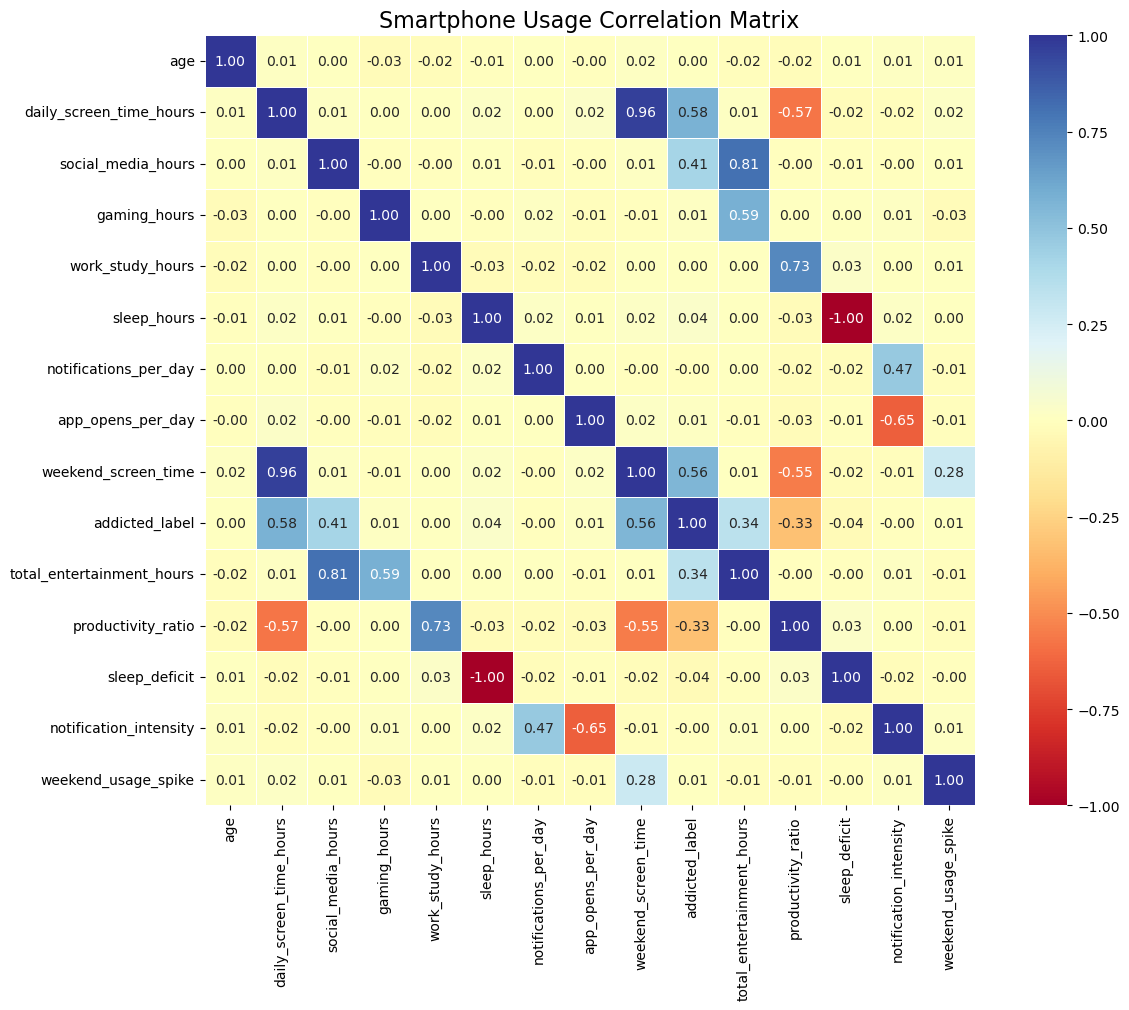

In [18]:
# computation of correlation matrix and creating a heatmap to visualise it
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    linewidths=0.7,
    square=True
)

plt.title("Smartphone Usage Correlation Matrix", fontsize=16)

plt.show()

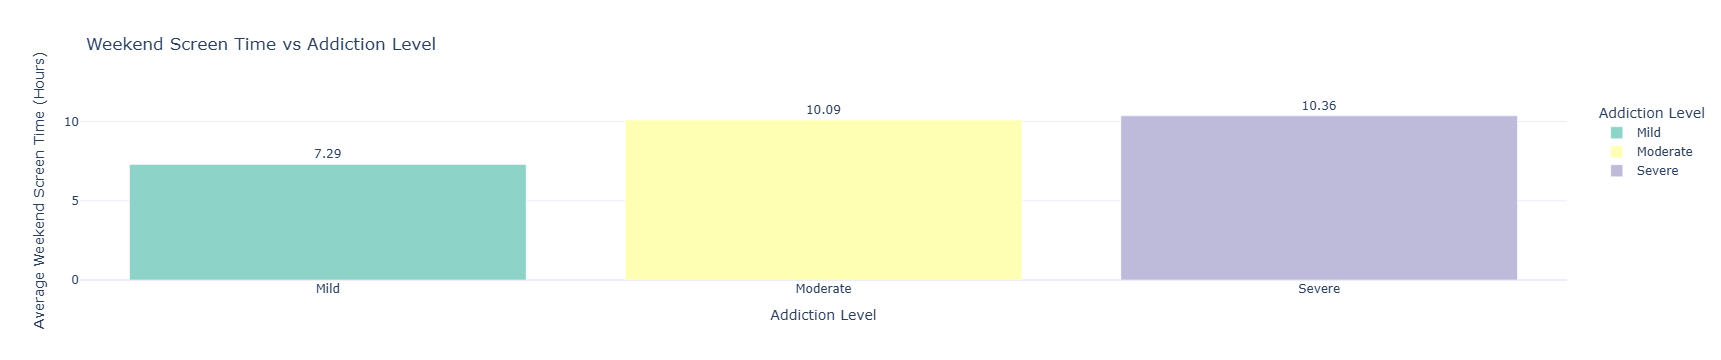

In [19]:
#Weekend Usage by Addiction Level
weekend_usage = (
    df.groupby("addiction_level")["weekend_screen_time"]
    .mean()
    .reset_index()
)
fig = px.bar(
    weekend_usage,
    x="addiction_level",
    y="weekend_screen_time",
    color="addiction_level",
    title="Weekend Screen Time vs Addiction Level",
    labels={
        "addiction_level": "Addiction Level",
        "weekend_screen_time": "Average Weekend Screen Time (Hours)"
    },
    color_discrete_sequence=px.colors.qualitative.Set3,
    text="weekend_screen_time"
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Addiction Level",
    yaxis_title="Average Weekend Screen Time (Hours)"
)
fig.update_layout(yaxis_range=[0, weekend_usage["weekend_screen_time"].max()+1])
fig.show()

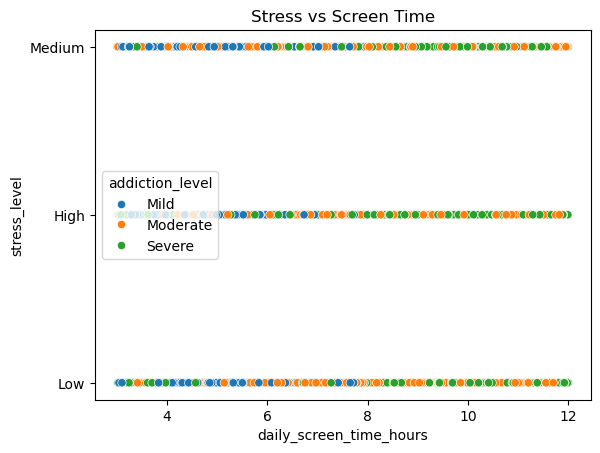

In [20]:
# Visualisation of stress vs screen time
sns.scatterplot(

    data=df,

    x="daily_screen_time_hours",

    y="stress_level",

    hue="addiction_level"

)

plt.title("Stress vs Screen Time")

plt.show()

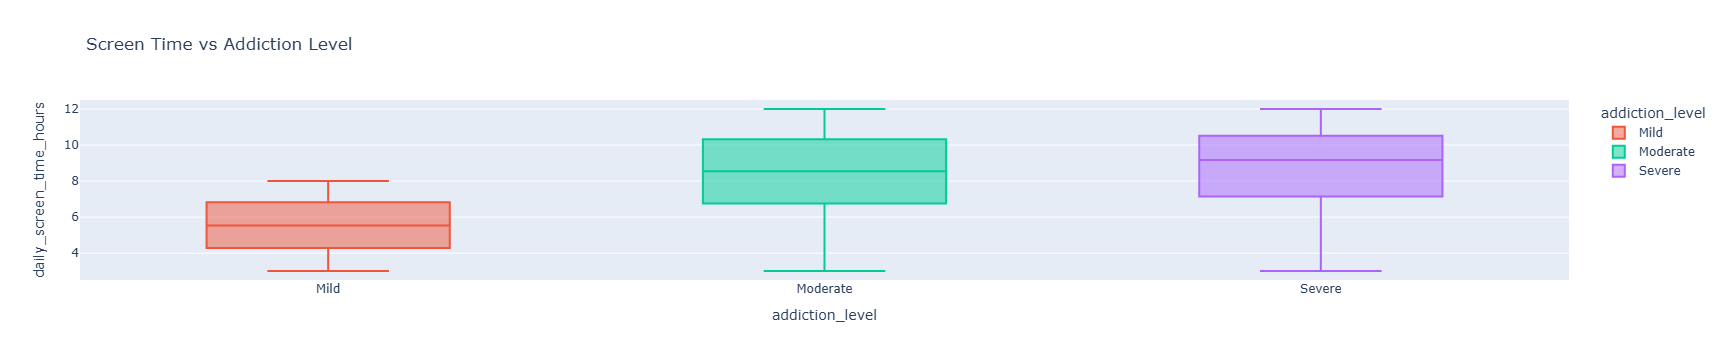

In [21]:
#visualisation of screen time vs addiction level
fig = px.box(

    df,

    x="addiction_level",

    y="daily_screen_time_hours",

    color="addiction_level",

    title="Screen Time vs Addiction Level"

)

fig.show()

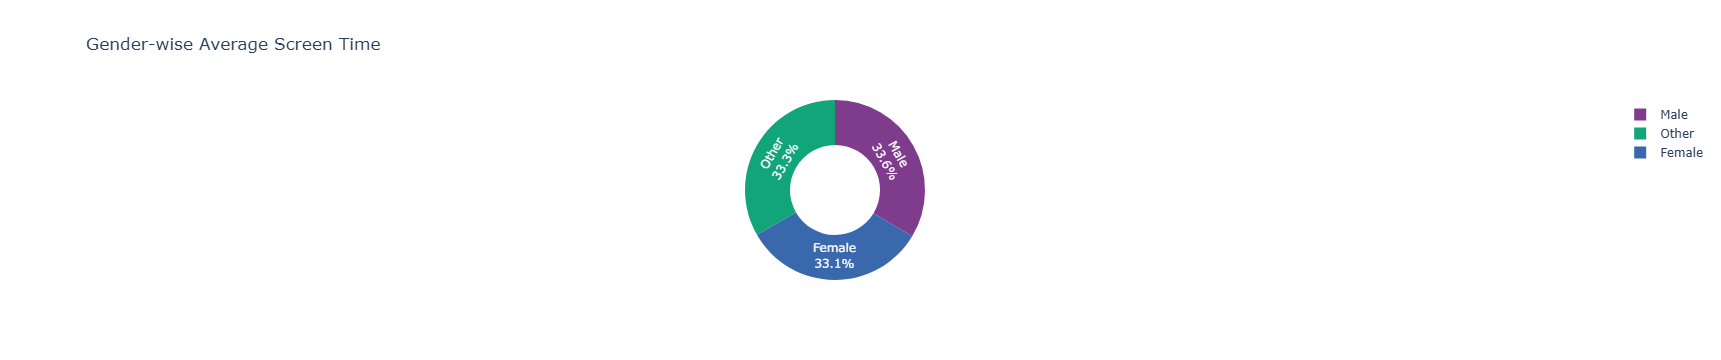

In [22]:
# Visualisation of gender wise average screen time analysis
gender_screen = df.groupby("gender")["daily_screen_time_hours"].mean().reset_index()
fig = px.pie(
    gender_screen,
    names="gender",
    values="daily_screen_time_hours",
    title="Gender-wise Average Screen Time",
    hole=0.5,   # makes it a donut chart
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textinfo="percent+label")
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Value: %{value}<br>Percentage: %{percent}"
)
fig.show()

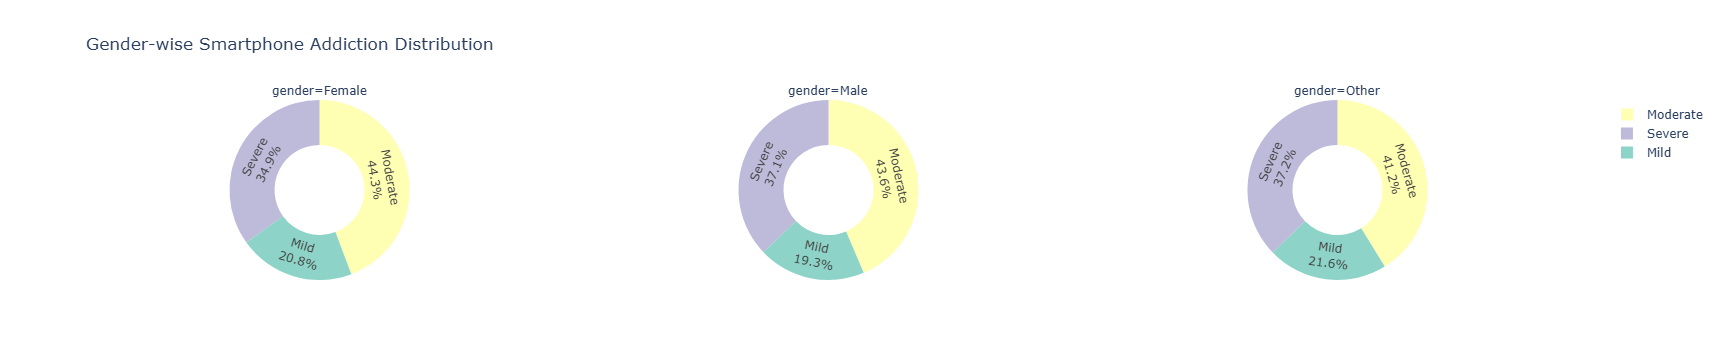

In [23]:
# Visualisation of Gender-wise Smartphone Addiction Distribution
gender_addiction = df.groupby(["gender","addiction_level"]).size().reset_index(name="count")
fig = px.pie(
    gender_addiction,
    names="addiction_level",
    values="count",
    color="addiction_level",
    facet_col="gender",
    title="Gender-wise Smartphone Addiction Distribution",
    hole=0.5,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(textinfo="percent+label")
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Value: %{value}<br>Percentage: %{percent}"
)
fig.show()

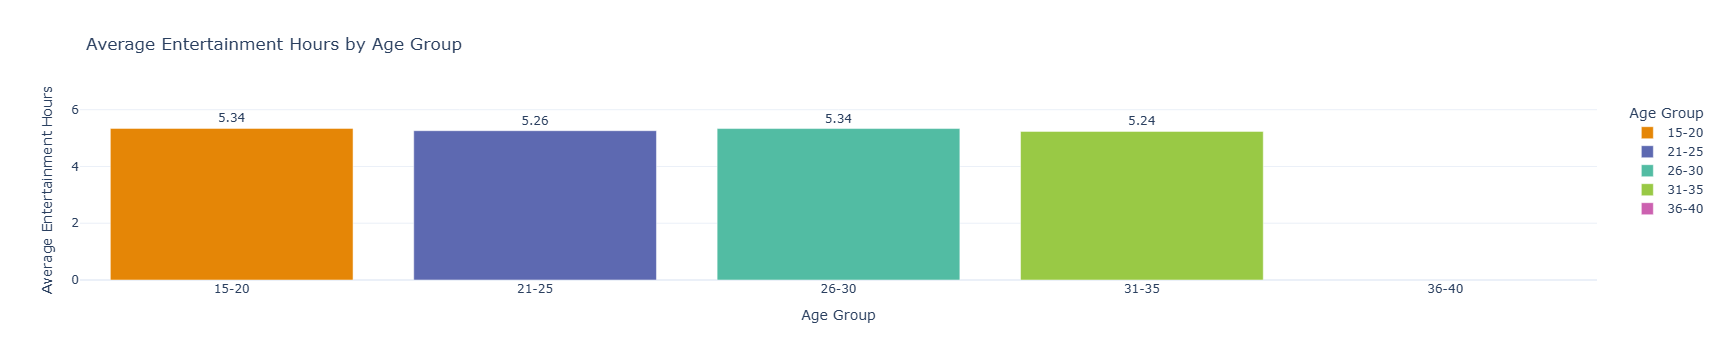

In [25]:
# Analysis of gender-wise total entertainment hours
age_entertainment = (
    df.groupby("age_group")["total_entertainment_hours"]
    .mean()
    .reset_index()
)
fig = px.bar(
    age_entertainment,
    x="age_group",
    y="total_entertainment_hours",
    color="age_group",
    title="Average Entertainment Hours by Age Group",
    labels={
        "age_group": "Age Group",
        "total_entertainment_hours": "Average Entertainment Hours"
    },
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(
    texttemplate='%{y:.2f}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Average Entertainment Hours",
    template="plotly_white"
)
fig.update_layout(yaxis_range=[0, age_entertainment["total_entertainment_hours"].max()+1])
fig.show()

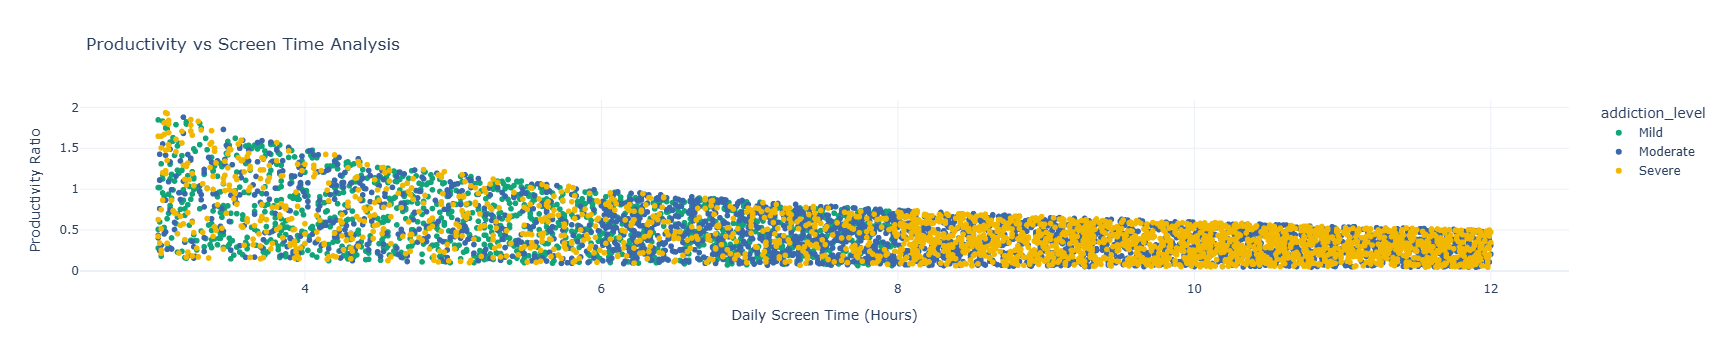

In [26]:
#Productivity vs Screen Time Analysis
fig = px.scatter(
    df,
    x="daily_screen_time_hours",
    y="productivity_ratio",
    color="addiction_level",
    title="Productivity vs Screen Time Analysis",
    labels={
        "daily_screen_time_hours": "Daily Screen Time (Hours)",
        "productivity_ratio": "Productivity Ratio"
    },
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(template="plotly_white")

fig.show()

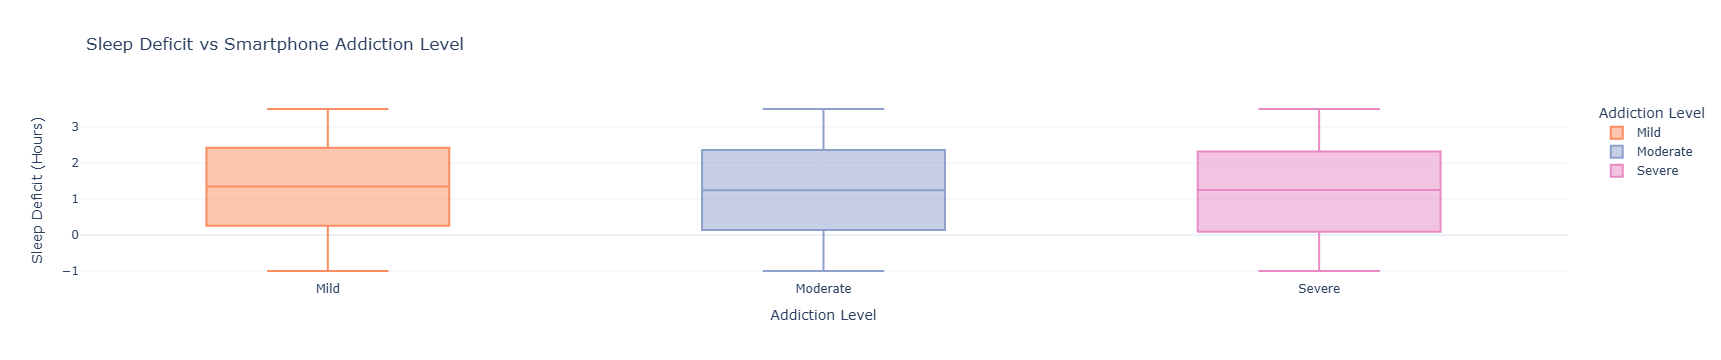

In [27]:
# visualisation of Sleep Deficit vs Smartphone Addiction Level
fig = px.box(
    df,
    x="addiction_level",
    y="sleep_deficit",
    color="addiction_level",
    title="Sleep Deficit vs Smartphone Addiction Level",
    labels={
        "addiction_level": "Addiction Level",
        "sleep_deficit": "Sleep Deficit (Hours)"
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(template="plotly_white")

fig.show()

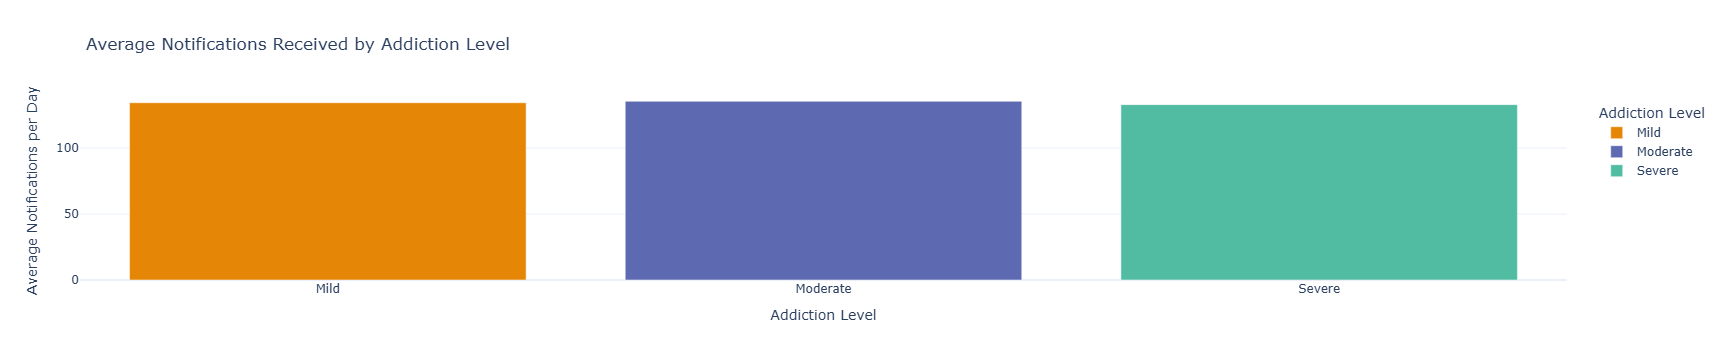

In [33]:
## Notification Analysis
notification_analysis = (
    df.groupby("addiction_level")["notifications_per_day"]
    .mean()
    .reset_index()
)
fig = px.bar(
    notification_analysis,
    x="addiction_level",
    y="notifications_per_day",
    color="addiction_level",
    title="Average Notifications Received by Addiction Level",
    labels={
        "addiction_level": "Addiction Level",
        "notifications_per_day": "Average Notifications per Day"
    },
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(texttemplate='%{y:.0f}', textposition='outside')

fig.update_layout(template="plotly_white")
fig.update_layout(yaxis_range=[0, notification_analysis["notifications_per_day"].max()+1])
fig.show()

In [34]:
# Analysis showing the adiiction levels
df.groupby("addiction_level")[[
    "daily_screen_time_hours",
    "sleep_deficit",
    "notifications_per_day",
    "productivity_ratio"
]].mean()

,daily_screen_time_hours,sleep_deficit,notifications_per_day,productivity_ratio
addiction_level,,,,
Mild,5.535062,1.339847,134.302986,0.621183
Moderate,8.351427,1.243184,135.382394,0.430654
Severe,8.604560,1.221327,132.867297,0.426993


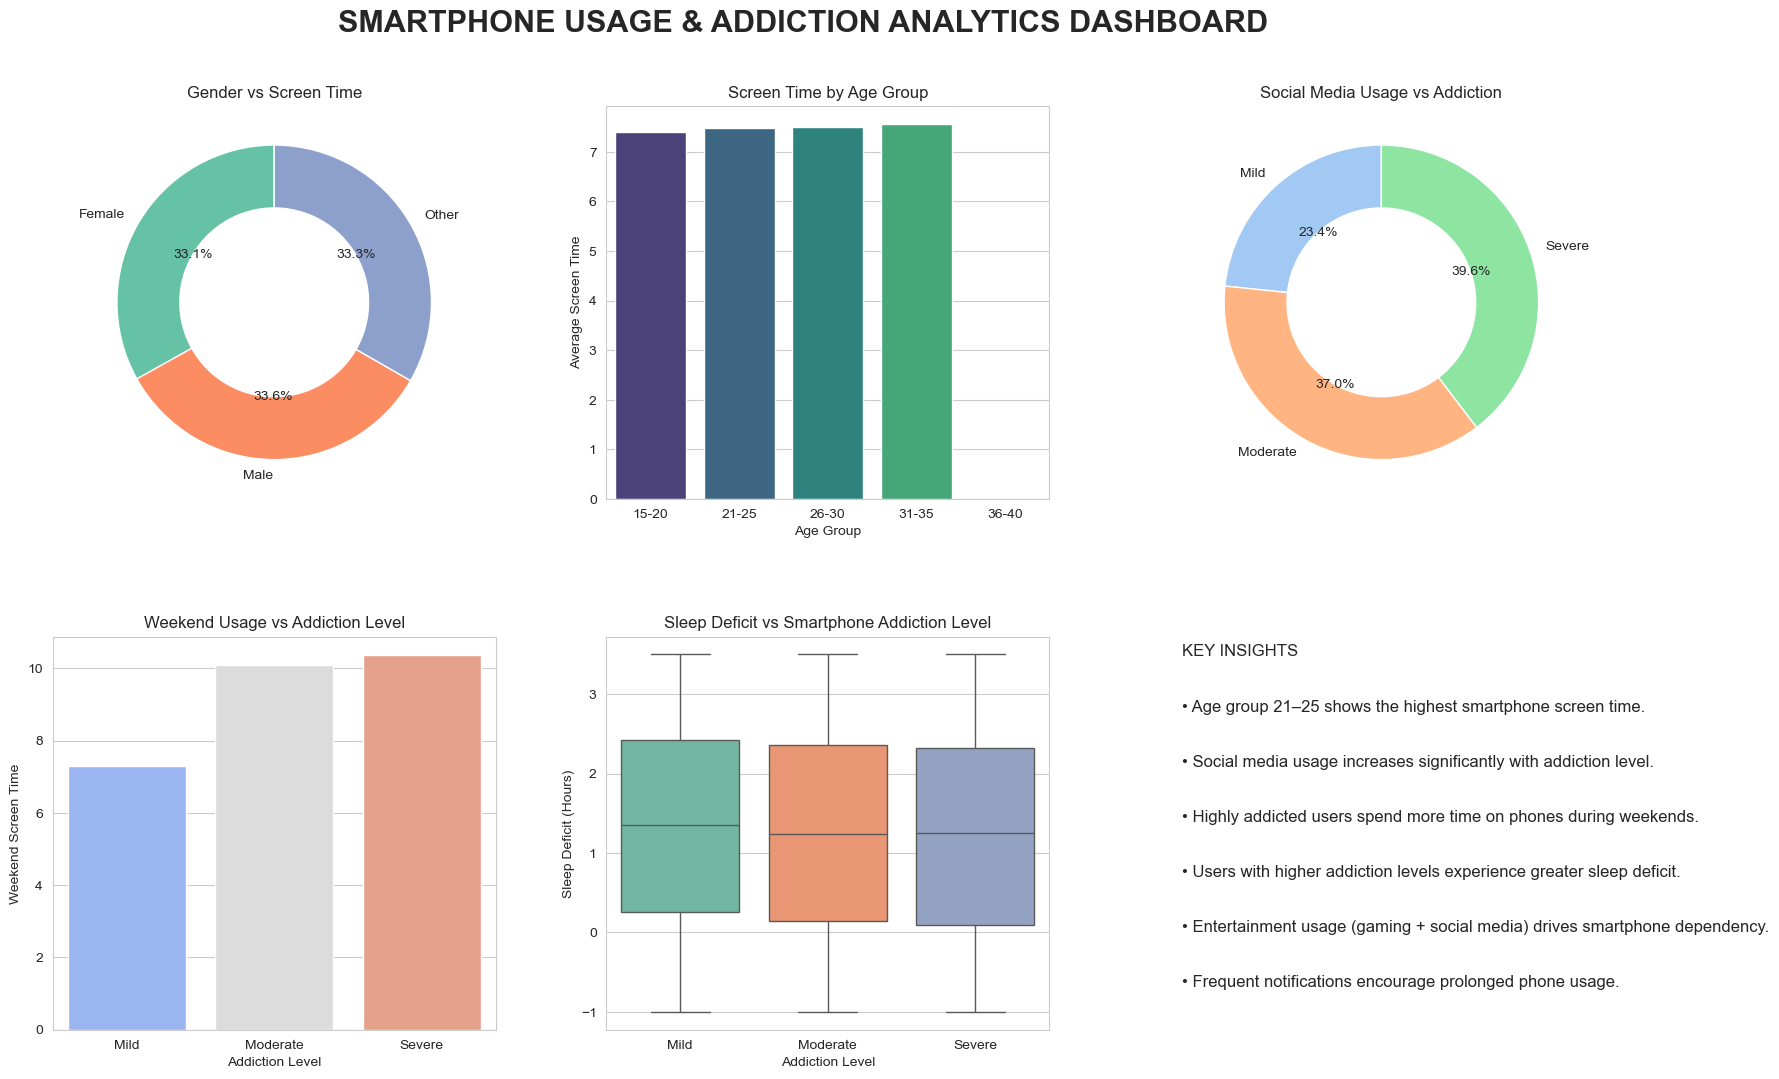

In [38]:
# DASHBOARD
sns.set_style("whitegrid")

gender_screen = df.groupby("gender")["daily_screen_time_hours"].mean()
age_screen = df.groupby("age_group")["daily_screen_time_hours"].mean()
social_media = df.groupby("addiction_level")["social_media_hours"].mean()
weekend_usage = df.groupby("addiction_level")["weekend_screen_time"].mean()

fig = plt.figure(figsize=(20,12))

fig.suptitle(
    "SMARTPHONE USAGE & ADDICTION ANALYTICS DASHBOARD",
    fontsize=22,
    fontweight="bold",
    y=0.96
)

gs = fig.add_gridspec(2,3, hspace=0.35, wspace=0.25)
# Gender vs Screen Time (Donut)
ax1 = fig.add_subplot(gs[0,0])

ax1.pie(
    gender_screen,
    labels=gender_screen.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2"),
    startangle=90,
    wedgeprops=dict(width=0.4)
)

ax1.set_title("Gender vs Screen Time")

# Age Group vs Screen Time

ax2 = fig.add_subplot(gs[0,1])

sns.barplot(
    x=age_screen.index,
    y=age_screen.values,
    palette="viridis",
    ax=ax2
)

ax2.set_title("Screen Time by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Average Screen Time")

# Social Media vs Addiction (Donut)

ax3 = fig.add_subplot(gs[0,2])

ax3.pie(
    social_media,
    labels=social_media.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    startangle=90,
    wedgeprops=dict(width=0.4)
)

ax3.set_title("Social Media Usage vs Addiction")

# Weekend Usage vs Addiction

ax4 = fig.add_subplot(gs[1,0])

sns.barplot(
    x=weekend_usage.index,
    y=weekend_usage.values,
    palette="coolwarm",
    ax=ax4
)

ax4.set_title("Weekend Usage vs Addiction Level")
ax4.set_xlabel("Addiction Level")
ax4.set_ylabel("Weekend Screen Time")

# Sleep Deficit vs Addiction

ax5 = fig.add_subplot(gs[1,1])

sns.boxplot(
    x="addiction_level",
    y="sleep_deficit",
    data=df,
    palette="Set2",
    ax=ax5
)

ax5.set_title("Sleep Deficit vs Smartphone Addiction Level")
ax5.set_xlabel("Addiction Level")
ax5.set_ylabel("Sleep Deficit (Hours)")

# INSIGHTS PANEL

ax6 = fig.add_subplot(gs[1,2])
ax6.axis("off")

insights = [
"KEY INSIGHTS",
"",
"• Age group 21–25 shows the highest smartphone screen time.",
"",
"• Social media usage increases significantly with addiction level.",
"",
"• Highly addicted users spend more time on phones during weekends.",
"",
"• Users with higher addiction levels experience greater sleep deficit.",
"",
"• Entertainment usage (gaming + social media) drives smartphone dependency.",
"",
"• Frequent notifications encourage prolonged phone usage."
]

for i, line in enumerate(insights):
    ax6.text(0.05, 0.95 - i*0.07, line, fontsize=12)

plt.show()